# WYNFLEX — Análisis Operativo de Entregas

Este notebook presenta el análisis de la operación logística de WYNFLEX a partir de los reportes semanales procesados por el pipeline de Data Engineering.

El objetivo es transformar los datos operativos consolidados en PostgreSQL en indicadores que permitan evaluar el desempeño de las entregas, identificar patrones de actividad, analizar la concentración por cliente y visualizar la distribución geográfica de los pedidos.

El análisis utiliza los datos procesados por el pipeline ETL y las herramientas de Analytics desarrolladas para el proyecto.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine


# Permite importar módulos desde src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


# Funciones de analytics
from src.analytics import (
    get_same_day_kpi,
    get_deliveries_by_status,
    get_deliveries_by_day,
    get_deliveries_by_client,
)


# Conexión a PostgreSQL
DATABASE_URL = (
    "postgresql+psycopg2://"
    "wynflex:wynflex@localhost:5432/wynflex"
)

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,
)


# Carpeta para guardar las visualizaciones
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "visualizaciones"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Entorno listo")

Entorno listo


## 1. Datos analizados

Se cargan desde PostgreSQL los registros consolidados de las entregas procesadas por el pipeline.

A partir de la información disponible se determinan:

- cantidad total de entregas analizadas;
- cantidad de días con actividad registrados;
- fechas de colecta y estado normalizadas para los análisis posteriores.

La cantidad de días analizados se calcula automáticamente según los datos disponibles, por lo que el período se actualiza a medida que se incorporan nuevas semanas al pipeline.

In [3]:
df_entregas = pd.read_sql_query(
    """
    SELECT
        numero_tracking,
        direccion,
        cp,
        fecha_colecta,
        fecha_estado,
        estado,
        nombre_fantasia,
        cadete
    FROM deliveries;
    """,
    engine
)

df_entregas["fecha_colecta"] = pd.to_datetime(
    df_entregas["fecha_colecta"],
    errors="coerce"
)

df_entregas["fecha_estado"] = pd.to_datetime(
    df_entregas["fecha_estado"],
    errors="coerce"
)

dias_analizados = (
    df_entregas["fecha_colecta"]
    .dt.date
    .nunique()
)

print(f"Entregas analizadas: {len(df_entregas):,}")
print(f"Días analizados: {dias_analizados}")

Entregas analizadas: 1,432
Días analizados: 51


## 2. Dataset geográfico de WYNFLEX

Como parte del proceso de análisis se construyó un **dataset geográfico propio de WYNFLEX** a partir de las direcciones de entrega.

El objetivo es transformar las direcciones operativas en información geográfica reutilizable, asociando cada ubicación con:

- barrio;
- latitud;
- longitud;
- código postal obtenido mediante geocoding;
- método utilizado para encontrar la dirección.

El proceso utiliza un archivo de cache que permite conservar los resultados ya obtenidos. De esta manera, cuando una dirección vuelve a aparecer en otra entrega o semana, se reutiliza la información existente y se evita realizar nuevamente la consulta.

### Estrategia de geocoding

Las direcciones nuevas se procesan mediante una estrategia en cascada:

1. **Dirección completa:** se intenta localizar la dirección original.
2. **Última palabra + altura + código postal:** si la búsqueda principal falla, se simplifica el nombre de la calle para reducir problemas causados por abreviaturas, nombres extensos o formatos inconsistentes.
3. **Intersección + código postal:** se utiliza para direcciones expresadas como cruces de calles, por ejemplo `Riestra y Portela` o `Riestra y Mariano Acosta`.
4. **No encontrada:** si ninguna estrategia obtiene un resultado, la dirección se conserva como `not_found` sin forzar una ubicación.

Una vez obtenido un resultado, el código postal del Excel se utiliza como **segunda capa de validación**, comparándolo con el código postal devuelto por el geocoder.

De esta manera, el dataset no solo almacena una ubicación, sino también información sobre **cómo fue encontrada y qué nivel de consistencia presenta**.

In [4]:
import re
import time
import requests


# ============================================================
# CONFIGURACIÓN
# ============================================================

CACHE_FILE = Path("geocoding_cache.csv")

df_cache = pd.read_csv(CACHE_FILE)


# ============================================================
# LIMPIEZA
# ============================================================

def limpiar_direccion_geocoding(direccion):
    """Limpieza básica de la dirección."""

    direccion = str(direccion).strip()

    # Quitar (R) y (C)
    direccion = re.sub(
        r"\s*\([RC]\)\s*",
        " ",
        direccion,
        flags=re.IGNORECASE,
    )

    # Limpiar espacios
    direccion = re.sub(
        r"\s+",
        " ",
        direccion,
    )

    return direccion.strip(" ,.")


# ============================================================
# ÚLTIMA PALABRA + ALTURA
# ============================================================

def ultima_palabra_con_altura(direccion):
    """
    Ejemplo:

    Calle Coronel Domingo Trole 105 (R)
    → Trole 105
    """

    direccion = limpiar_direccion_geocoding(
        direccion
    )

    # Buscar la altura
    match = re.search(
        r"\b(\d{2,5})\b",
        direccion
    )

    if not match:
        return None

    altura = match.group(1)

    # Todo lo anterior al número
    calle = direccion[:match.start()].strip()

    # Limpiar puntuación
    calle = re.sub(
        r"[.,]",
        " ",
        calle
    )

    calle = re.sub(
        r"\s+",
        " ",
        calle
    ).strip()

    palabras = calle.split()

    if not palabras:
        return None

    return f"{palabras[-1]} {altura}"


# ============================================================
# INTERSECCIONES
# ============================================================

def extraer_interseccion(direccion):
    """
    Detecta específicamente:

    Riestra y Portela
    Riestra y Mariano Acosta
    Avenida Riestra y Avenida Mariano Acosta
    """

    direccion = limpiar_direccion_geocoding(
        direccion
    )

    # Quitar prefijos de calle/avenida
    direccion = re.sub(
        r"\b(calle|avenida|av\.|pasaje|pje\.)\s+",
        "",
        direccion,
        flags=re.IGNORECASE,
    )

    direccion = re.sub(
        r"\s+",
        " ",
        direccion
    ).strip()

    # Debe contener exactamente una separación por "y"
    partes = re.split(
        r"\s+\by\b\s+",
        direccion,
        flags=re.IGNORECASE,
    )

    if len(partes) != 2:
        return None

    calle_1 = partes[0].strip(" ,.")
    calle_2 = partes[1].strip(" ,.")

    if not calle_1 or not calle_2:
        return None

    return f"{calle_1} y {calle_2}"


# ============================================================
# NOMINATIM
# ============================================================

def buscar_nominatim(consulta):
    """Realiza una consulta a Nominatim."""

    response = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={
            "q": consulta,
            "format": "json",
            "addressdetails": 1,
            "limit": 1,
        },
        headers={
            "User-Agent": "WYNFLEX-Analytics/1.0"
        },
        timeout=10,
    )

    response.raise_for_status()

    return response.json()


# ============================================================
# CONSTRUIR RESULTADO
# ============================================================

def construir_resultado(
    data,
    direccion,
    metodo,
    direccion_limpia,
):
    """Convierte la respuesta del geocoder."""

    result = data[0]
    address = result.get("address", {})

    return {
        "direccion_original": direccion,
        "direccion_limpia": direccion_limpia,
        "lat": float(result["lat"]),
        "lon": float(result["lon"]),
        "barrio": (
            address.get("neighbourhood")
            or address.get("suburb")
            or address.get("city_district")
        ),
        "cp_geocodificado": address.get("postcode"),
        "display_name": result.get(
            "display_name"
        ),
        "geocoding_status": metodo,
    }


# ============================================================
# GEOCODING EN CASCADA
# ============================================================

def geocodificar(direccion, cp):

    direccion = str(direccion).strip()
    cp = str(cp).strip()

    # --------------------------------------------------------
    # 1. DIRECCIÓN COMPLETA
    # --------------------------------------------------------

    direccion_limpia = limpiar_direccion_geocoding(
        direccion
    )

    consulta_1 = (
        f"{direccion_limpia}, "
        f"Ciudad Autónoma de Buenos Aires, Argentina"
    )

    try:
        data = buscar_nominatim(
            consulta_1
        )
    except Exception:
        data = []

    if data:
        return construir_resultado(
            data,
            direccion,
            "found",
            direccion_limpia,
        )

    time.sleep(1)

    # --------------------------------------------------------
    # 2. ÚLTIMA PALABRA + ALTURA + CP
    # --------------------------------------------------------

    variante = ultima_palabra_con_altura(
        direccion
    )

    if variante:

        consulta_2 = (
            f"{variante}, {cp}, "
            f"Ciudad Autónoma de Buenos Aires, Argentina"
        )

        try:
            data = buscar_nominatim(
                consulta_2
            )
        except Exception:
            data = []

        if data:
            return construir_resultado(
                data,
                direccion,
                "found_palabra",
                variante,
            )

        time.sleep(1)

    # --------------------------------------------------------
    # 3. INTERSECCIÓN + CP
    # --------------------------------------------------------

    interseccion = extraer_interseccion(
        direccion
    )

    if interseccion:

        consulta_3 = (
            f"{interseccion}, {cp}, "
            f"Ciudad Autónoma de Buenos Aires, Argentina"
        )

        try:
            data = buscar_nominatim(
                consulta_3
            )
        except Exception:
            data = []

        if data:
            return construir_resultado(
                data,
                direccion,
                "found_interseccion",
                interseccion,
            )

    # --------------------------------------------------------
    # 4. NO ENCONTRADA
    # --------------------------------------------------------

    return {
        "direccion_original": direccion,
        "direccion_limpia": direccion_limpia,
        "lat": None,
        "lon": None,
        "barrio": None,
        "cp_geocodificado": None,
        "display_name": None,
        "geocoding_status": "not_found",
    }


# ============================================================
# DIRECCIONES ÚNICAS ACTUALES
# ============================================================

df_direcciones_actuales = (
    df_entregas[
        [
            "direccion",
            "cp",
        ]
    ]
    .dropna(
        subset=["direccion"]
    )
    .drop_duplicates(
        subset=["direccion"]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# DETECTAR NUEVAS DIRECCIONES
# ============================================================

direcciones_cache = set(
    df_cache[
        "direccion_original"
    ]
    .dropna()
    .astype(str)
)

df_nuevas = df_direcciones_actuales[
    ~df_direcciones_actuales[
        "direccion"
    ]
    .astype(str)
    .isin(
        direcciones_cache
    )
].copy()


print(
    f"Direcciones únicas actuales: "
    f"{len(df_direcciones_actuales):,}"
)

print(
    f"Direcciones en cache: "
    f"{len(df_cache):,}"
)

print(
    f"Nuevas para geocoding: "
    f"{len(df_nuevas):,}"
)


# ============================================================
# PROCESAR SOLO NUEVAS
# ============================================================

recuperadas = 0

for n, (_, row) in enumerate(
    df_nuevas.iterrows(),
    start=1,
):

    direccion = row["direccion"]
    cp = row["cp"]

    resultado = geocodificar(
        direccion,
        cp,
    )

    # Agregar resultado al cache
    df_cache = pd.concat(
        [
            df_cache,
            pd.DataFrame([resultado]),
        ],
        ignore_index=True,
    )

    # Guardar inmediatamente
    df_cache.to_csv(
        CACHE_FILE,
        index=False,
    )

    if resultado[
        "geocoding_status"
    ] != "not_found":

        recuperadas += 1

        print(
            f"[{n}/{len(df_nuevas)}] ✅ "
            f"{direccion} → "
            f"{resultado['geocoding_status']}"
        )

    else:

        print(
            f"[{n}/{len(df_nuevas)}] ❌ "
            f"{direccion}"
        )

    # Respetar Nominatim
    time.sleep(1)


# ============================================================
# VALIDACIÓN DEL CP
# ============================================================

def normalizar_cp(cp):

    if pd.isna(cp):
        return None

    match = re.search(
        r"\d{4}",
        str(cp)
    )

    if match:
        return match.group()

    return None


df_cache["cp_excel_4"] = (
    df_cache["direccion_original"]
    .map(
        df_direcciones_actuales
        .set_index("direccion")["cp"]
        .to_dict()
    )
    .apply(normalizar_cp)
)

df_cache["cp_geo_4"] = (
    df_cache["cp_geocodificado"]
    .apply(normalizar_cp)
)


df_cache["validacion_cp"] = "Sin validar"


mask_encontradas = (
    df_cache["geocoding_status"]
    != "not_found"
)

mask_cp_coincide = (
    mask_encontradas
    & df_cache["cp_excel_4"].notna()
    & df_cache["cp_geo_4"].notna()
    & (
        df_cache["cp_excel_4"]
        == df_cache["cp_geo_4"]
    )
)

mask_cp_discrepante = (
    mask_encontradas
    & ~mask_cp_coincide
)

df_cache.loc[
    mask_cp_coincide,
    "validacion_cp"
] = "✅ Coincide"

df_cache.loc[
    mask_cp_discrepante,
    "validacion_cp"
] = "⚠️ Revisar"


# ============================================================
# RESUMEN
# ============================================================

print("\nRESULTADO FINAL")

print(
    df_cache[
        "geocoding_status"
    ].value_counts()
)

print(
    "\nValidación CP:"
)

print(
    df_cache[
        "validacion_cp"
    ].value_counts()
)

print(
    f"\nTotal cache: "
    f"{len(df_cache):,}"
)

Direcciones únicas actuales: 1,338
Direcciones en cache: 1,338
Nuevas para geocoding: 0

RESULTADO FINAL
geocoding_status
found            928
found_palabra    393
not_found         16
found_v2           1
Name: count, dtype: int64

Validación CP:
validacion_cp
✅ Coincide     852
⚠️ Revisar     470
Sin validar     16
Name: count, dtype: int64

Total cache: 1,338


## 3. KPI principal — Eficiencia de entregas

Este indicador resume el desempeño general de la operación durante el período analizado.

El KPI se obtiene a partir de las entregas consolidadas en PostgreSQL y permite evaluar el nivel de cumplimiento de los pedidos según su fecha de colecta y fecha de estado.

Este indicador funciona como una primera medida de desempeño antes de analizar con mayor detalle los estados, la evolución diaria, los clientes y la distribución geográfica.

In [5]:
kpi = get_same_day_kpi()
kpi

,total_entregadas,entregadas_mismo_dia,entregadas_despues,same_day_rate_pct
0,1396,1345,51,96.35


## 4. Entregas por estado — Eficiencia del cadete

Este análisis muestra la distribución de las entregas según el estado registrado en la operación.

Los diferentes estados permiten observar el recorrido de los pedidos desde la colecta hasta su resultado final.

Además, se incorpora la **eficiencia del cadete**, calculada como el porcentaje de entregas que alcanzaron el estado **"Entregado"** sobre el total de entregas analizadas.

Este indicador permite evaluar de forma rápida el nivel de cumplimiento de la operación y detectar qué proporción de los pedidos finaliza correctamente.

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/01_entregas_por_estado.png


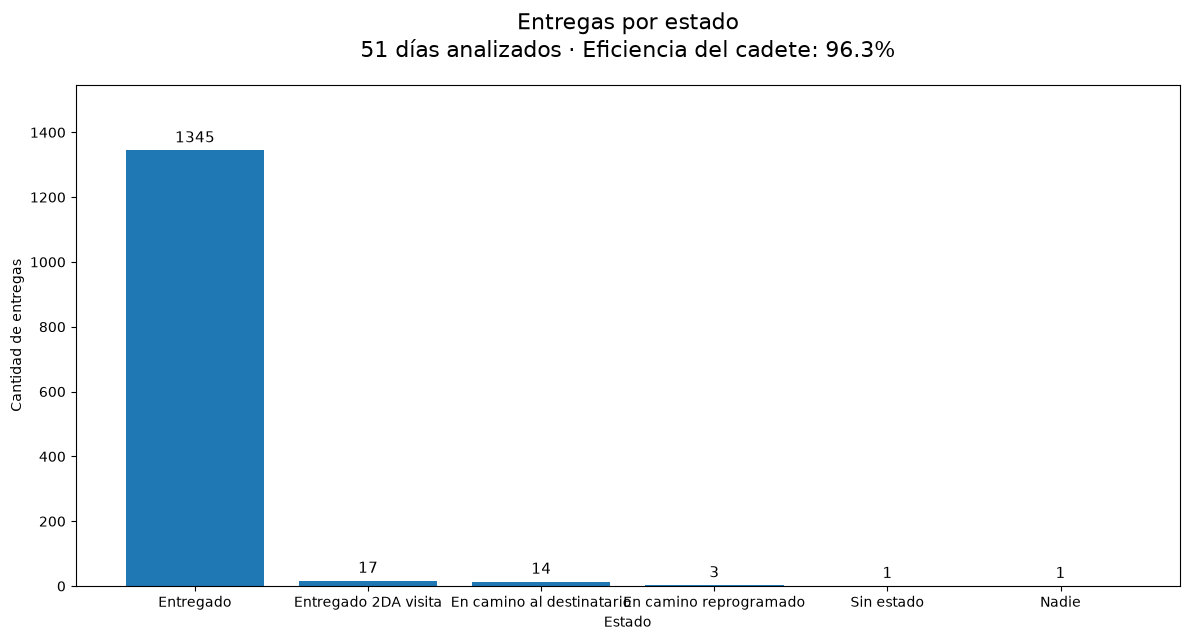

In [13]:
# ============================================================
# ENTREGAS POR ESTADO
# ============================================================

df_status = get_deliveries_by_status().copy()

# Limpiar estados para que Matplotlib pueda graficarlos
df_status["estado"] = (
    df_status["estado"]
    .fillna("Sin estado")
    .astype(str)
    .str.strip()
)

df_status["total_entregas"] = pd.to_numeric(
    df_status["total_entregas"],
    errors="coerce"
).fillna(0)


# ============================================================
# KPI SAME DAY
# ============================================================

total_entregadas = int(kpi.loc[0, "total_entregadas"])

entregadas_mismo_dia = int(
    kpi.loc[0, "entregadas_mismo_dia"]
)

eficiencia = float(
    kpi.loc[0, "same_day_rate_pct"]
)


# ============================================================
# DATOS PARA EL GRÁFICO
# ============================================================

df_plot = df_status.copy()

# La barra "Entregado" muestra solamente
# las entregas realizadas el mismo día
df_plot.loc[
    df_plot["estado"].str.lower() == "entregado",
    "total_entregas"
] = entregadas_mismo_dia


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6.5))

bars = ax.bar(
    df_plot["estado"],
    df_plot["total_entregas"]
)

# Valores sobre las barras
ax.bar_label(
    bars,
    padding=3,
    fontsize=11
)

ax.set_title(
    f"Entregas por estado\n"
    f"{dias_analizados} días analizados · "
    f"Eficiencia del cadete: {eficiencia:.1f}%",
    fontsize=16,
    pad=20
)

ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad de entregas")

ax.set_ylim(
    0,
    df_plot["total_entregas"].max() * 1.15
)

plt.tight_layout()


# ============================================================
# GUARDAR PNG
# ============================================================

ruta = OUTPUT_DIR / "01_entregas_por_estado.png"

fig.savefig(
    ruta,
    dpi=150,
    bbox_inches="tight"
)

print(f"Gráfico guardado en: {ruta}")

plt.show()

## 5. Entregas realizadas por día

Este análisis muestra la evolución del volumen de entregas a lo largo del período analizado.

La distribución diaria permite identificar patrones de actividad, días de mayor carga operativa y posibles variaciones en la demanda.

La visualización utiliza barras verticales para facilitar la comparación entre jornadas y detectar rápidamente los días con mayor cantidad de entregas.

Este indicador puede ser útil para la planificación de recorridos, organización de recursos y anticipación de jornadas de mayor volumen.

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/02_entregas_por_dia.png


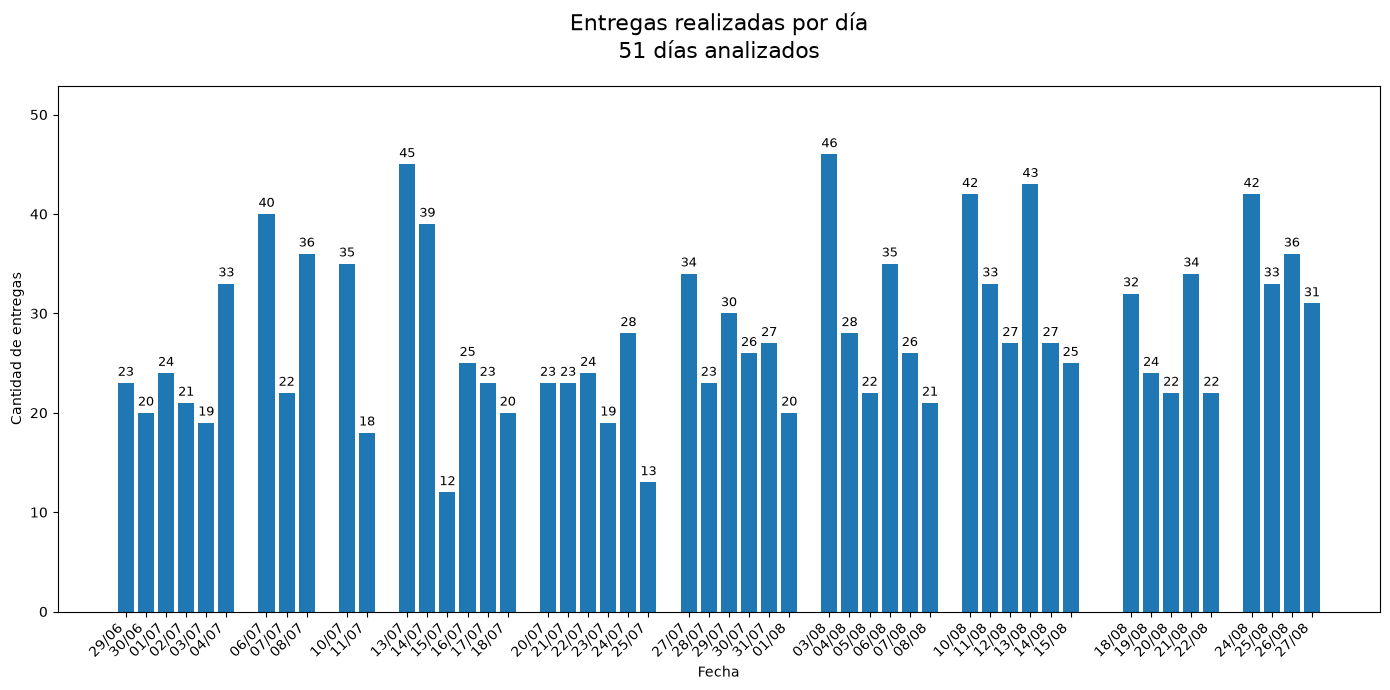

In [7]:
# ============================================================
# ENTREGAS REALIZADAS POR DÍA
# ============================================================

df_day = get_deliveries_by_day().copy()

df_day["fecha"] = pd.to_datetime(
    df_day["fecha"],
    errors="coerce"
)

df_day["total_entregas"] = pd.to_numeric(
    df_day["total_entregas"],
    errors="coerce"
).fillna(0)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    df_day["fecha"],
    df_day["total_entregas"]
)

# Valores sobre las barras
ax.bar_label(
    bars,
    padding=3,
    fontsize=9
)

ax.set_title(
    f"Entregas realizadas por día\n"
    f"{dias_analizados} días analizados",
    fontsize=16,
    pad=20
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de entregas")

ax.set_xticks(df_day["fecha"])
ax.set_xticklabels(
    df_day["fecha"].dt.strftime("%d/%m"),
    rotation=45,
    ha="right"
)

ax.set_ylim(
    0,
    df_day["total_entregas"].max() * 1.15
)

plt.tight_layout()


# Guardar PNG
ruta = OUTPUT_DIR / "02_entregas_por_dia.png"

fig.savefig(
    ruta,
    dpi=150,
    bbox_inches="tight"
)

print(f"Gráfico guardado en: {ruta}")

plt.show()

## 6. Principales clientes por cantidad de entregas

Este análisis identifica los clientes que concentran el mayor volumen de entregas durante el período analizado.

Se presentan los **Top 30 clientes** mediante barras horizontales, lo que permite comparar fácilmente el nivel de actividad de cada cuenta.

El indicador permite detectar:

- clientes con mayor volumen operativo;
- concentración de la actividad en determinadas cuentas;
- clientes que pueden requerir una planificación logística específica;
- oportunidades para futuros análisis de facturación, costos y rentabilidad.

> **Nota:** el volumen de entregas representa actividad operativa y no necesariamente rentabilidad. Para evaluar la rentabilidad de cada cliente será necesario incorporar ingresos, costos y margen.

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/03_top_30_clientes.png


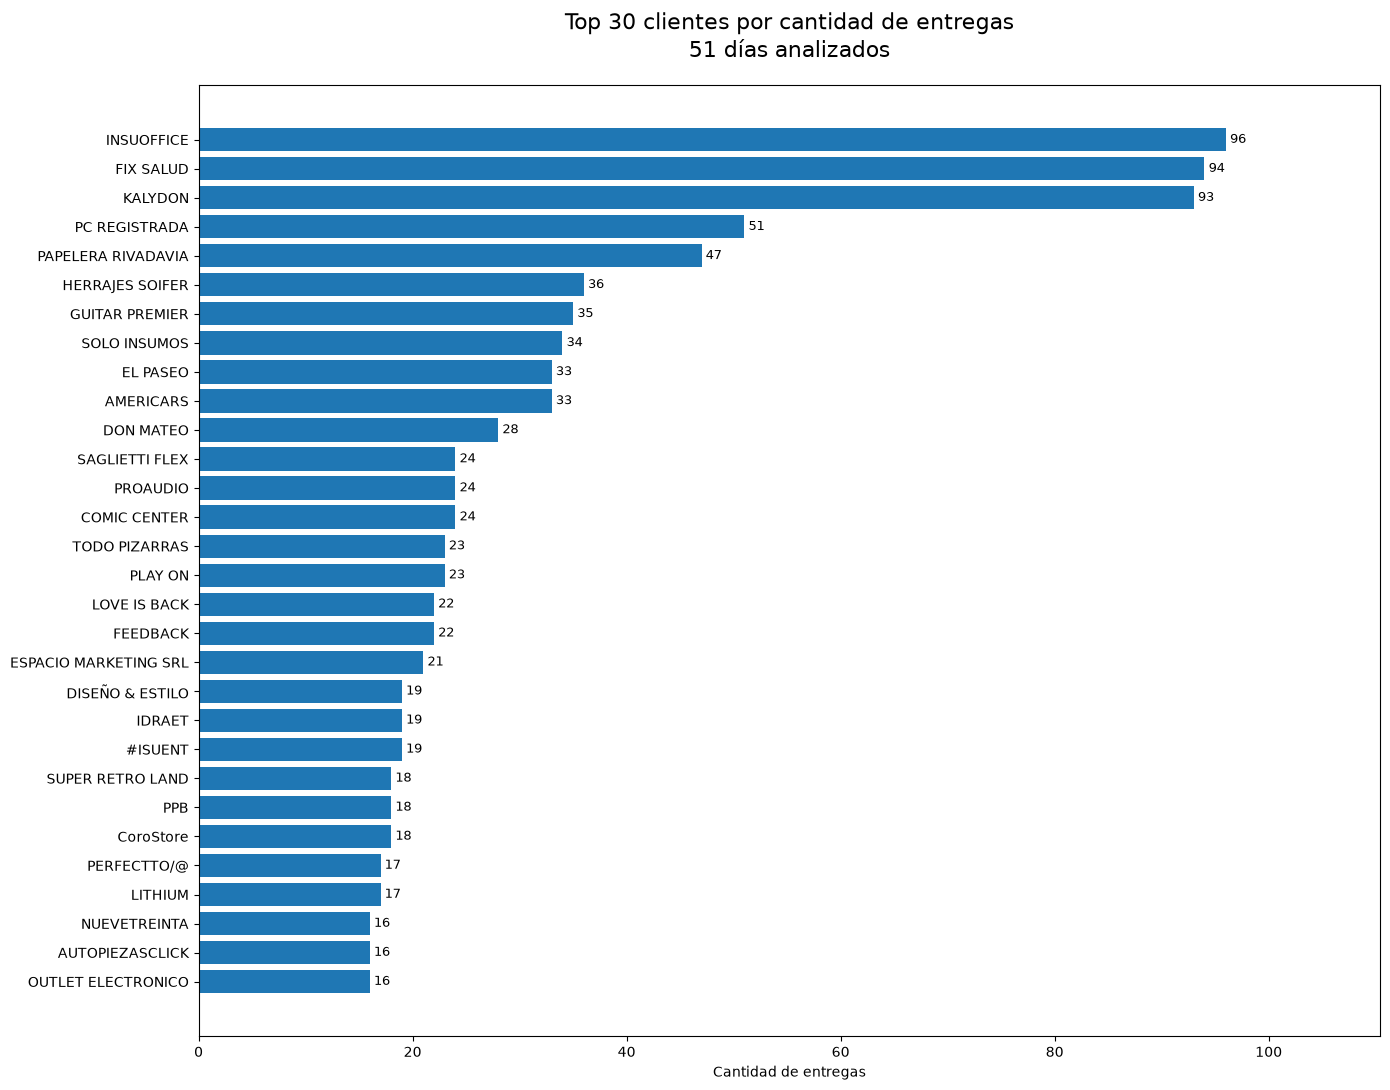

In [8]:
# ============================================================
# TOP 30 CLIENTES POR CANTIDAD DE ENTREGAS
# ============================================================

df_cliente = get_deliveries_by_client().copy()

df_cliente["total_entregas"] = pd.to_numeric(
    df_cliente["total_entregas"],
    errors="coerce"
).fillna(0)

df_cliente["nombre_fantasia"] = (
    df_cliente["nombre_fantasia"]
    .fillna("Sin cliente")
    .astype(str)
    .str.strip()
)

df_cliente_top = (
    df_cliente
    .sort_values(
        "total_entregas",
        ascending=False
    )
    .head(30)
    .sort_values(
        "total_entregas",
        ascending=True
    )
)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 11))

bars = ax.barh(
    df_cliente_top["nombre_fantasia"],
    df_cliente_top["total_entregas"]
)

# Valores al final de las barras
ax.bar_label(
    bars,
    padding=3,
    fontsize=9
)

ax.set_title(
    f"Top 30 clientes por cantidad de entregas\n"
    f"{dias_analizados} días analizados",
    fontsize=16,
    pad=20
)

ax.set_xlabel("Cantidad de entregas")
ax.set_ylabel("")

ax.set_xlim(
    0,
    df_cliente_top["total_entregas"].max() * 1.15
)

plt.tight_layout()

# Guardar PNG
ruta = OUTPUT_DIR / "03_top_30_clientes.png"

fig.savefig(
    ruta,
    dpi=150,
    bbox_inches="tight"
)

print(f"Gráfico guardado en: {ruta}")

plt.show()

## 7. Dataset geográfico de WYNFLEX

El proyecto cuenta con un **dataset geográfico propio de WYNFLEX**, construido a partir de las direcciones de entrega y almacenado en un archivo de cache.

En esta etapa se identifican las direcciones únicas presentes en las entregas y se comparan con las direcciones que ya forman parte del dataset geográfico.

El objetivo es:

- evitar procesar nuevamente direcciones ya conocidas;
- detectar nuevas ubicaciones incorporadas por las últimas semanas;
- mantener un dataset geográfico acumulativo;
- reutilizar la información obtenida previamente para posteriores análisis.

De esta manera, una misma dirección puede aparecer en múltiples entregas y días sin requerir un nuevo proceso de geocoding.

**Resultado esperado:**

> Direcciones únicas actuales − Direcciones existentes en cache = Nuevas direcciones para geocoding.

In [9]:
CACHE_FILE = Path("geocoding_cache.csv")

df_cache = pd.read_csv(
    CACHE_FILE
)

df_direcciones_actuales = (
    df_entregas[
        [
            "direccion",
            "cp"
        ]
    ]
    .dropna(
        subset=["direccion"]
    )
    .drop_duplicates(
        subset=["direccion"]
    )
    .reset_index(
        drop=True
    )
)

direcciones_cache = set(
    df_cache["direccion_original"]
    .dropna()
    .astype(str)
)

df_nuevas = df_direcciones_actuales[
    ~df_direcciones_actuales["direccion"]
    .astype(str)
    .isin(direcciones_cache)
].copy()

print(
    f"Direcciones únicas actuales: "
    f"{len(df_direcciones_actuales):,}"
)

print(
    f"Direcciones en cache: "
    f"{len(df_cache):,}"
)

print(
    f"Direcciones nuevas: "
    f"{len(df_nuevas):,}"
)

Direcciones únicas actuales: 1,338
Direcciones en cache: 1,338
Direcciones nuevas: 0


## 8. Integración de la información geográfica

Una vez procesadas las direcciones, la información geográfica se integra con los registros originales de entregas mediante la dirección como clave de referencia.

De esta forma, cada entrega puede quedar asociada con:

- barrio;
- latitud;
- longitud;
- código postal geocodificado;
- método utilizado para obtener la ubicación.

También se controla la cobertura del enriquecimiento geográfico, mostrando cuántas entregas tienen un barrio identificado y cuántas permanecen sin información geográfica.

Esto permite evaluar la calidad y cobertura del dataset geográfico antes de utilizarlo en los análisis por zona.

In [10]:
df_geo_final = df_entregas.merge(
    df_cache[
        [
            "direccion_original",
            "lat",
            "lon",
            "barrio",
            "cp_geocodificado",
            "geocoding_status",
        ]
    ],
    left_on="direccion",
    right_on="direccion_original",
    how="left",
)

print(
    f"Total entregas: "
    f"{len(df_geo_final):,}"
)

print(
    f"Con barrio: "
    f"{df_geo_final['barrio'].notna().sum():,}"
)

print(
    f"Sin barrio: "
    f"{df_geo_final['barrio'].isna().sum():,}"
)

Total entregas: 1,432
Con barrio: 1,414
Sin barrio: 18


## 9. Distribución geográfica de los pedidos

Este análisis utiliza el dataset geográfico de WYNFLEX para identificar los barrios que concentran el mayor flujo de entregas.

Se consideran únicamente los pedidos con estado **"Entregado"** y con un barrio geográfico identificado.

Para evitar fragmentaciones en la clasificación, se normalizan determinados nombres de zonas. Por ejemplo, **"Barrio Coreano" se agrupa dentro de "Flores"** para este análisis.

El gráfico presenta el **Top 15 de barrios por cantidad de pedidos**, permitiendo identificar rápidamente las zonas con mayor concentración de actividad.

Esta información puede utilizarse para:

- identificar zonas de mayor demanda;
- analizar la distribución territorial de la operación;
- detectar concentraciones de recorridos;
- contribuir a la planificación y optimización de rutas.

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/04_top_15_barrios.png


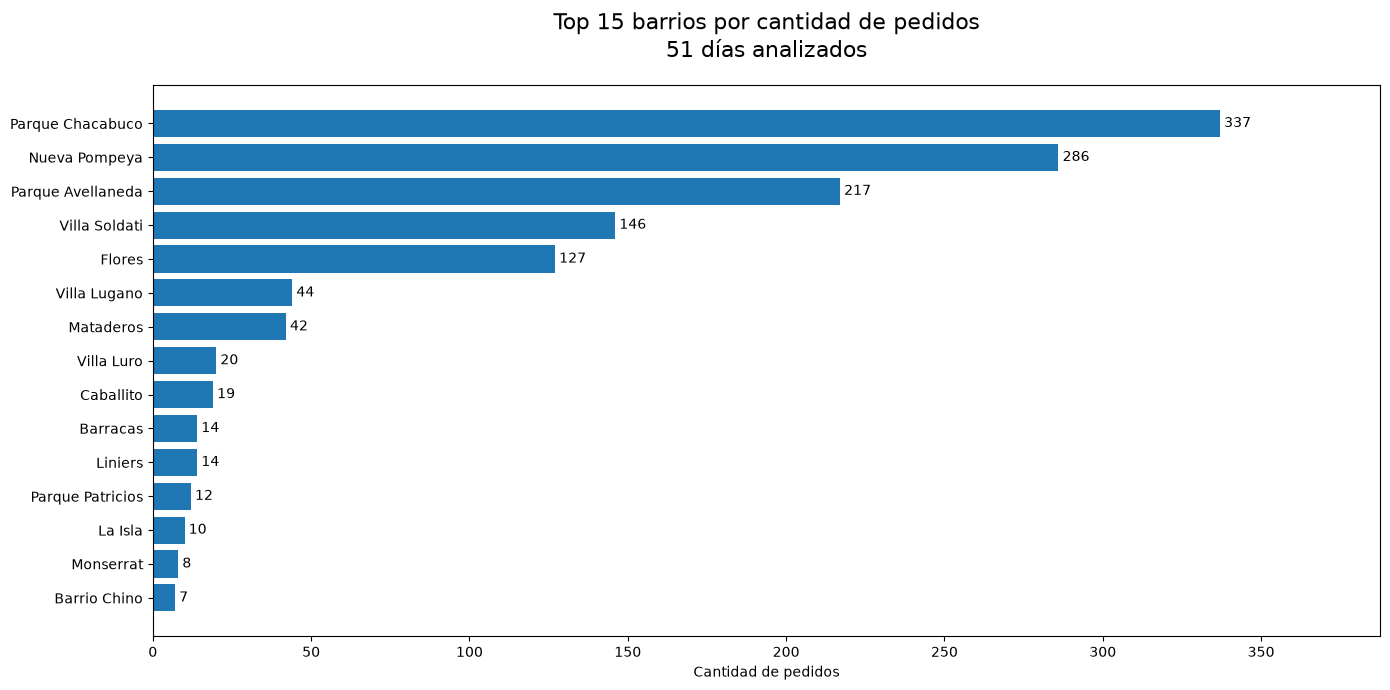

In [11]:
# ============================================================
# PEDIDOS POR BARRIO — TOP 15
# ============================================================

df_geo_final["barrio"] = (
    df_geo_final["barrio"]
    .replace({
        "Barrio Coreano": "Flores",
    })
)

df_pedidos_barrio = (
    df_geo_final[
        (df_geo_final["barrio"].notna()) &
        (df_geo_final["estado"].str.lower() == "entregado")
    ]
    .groupby("barrio")
    .agg(
        total_pedidos=("numero_tracking", "count")
    )
    .reset_index()
    .sort_values(
        "total_pedidos",
        ascending=False
    )
)

df_pedidos_barrio_top = (
    df_pedidos_barrio
    .head(15)
    .sort_values(
        "total_pedidos",
        ascending=True
    )
)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    df_pedidos_barrio_top["barrio"],
    df_pedidos_barrio_top["total_pedidos"]
)

ax.bar_label(
    bars,
    padding=3,
    fontsize=10
)

ax.set_title(
    f"Top 15 barrios por cantidad de pedidos\n"
    f"{dias_analizados} días analizados",
    fontsize=16,
    pad=20
)

ax.set_xlabel("Cantidad de pedidos")
ax.set_ylabel("")

ax.set_xlim(
    0,
    df_pedidos_barrio_top["total_pedidos"].max() * 1.15
)

plt.tight_layout()

# Guardar PNG
ruta = OUTPUT_DIR / "04_top_15_barrios.png"

fig.savefig(
    ruta,
    dpi=150,
    bbox_inches="tight"
)

print(f"Gráfico guardado en: {ruta}")

plt.show()

## 7. Evolución del flujo de pedidos por cliente

Este análisis muestra la variación diaria del volumen de pedidos que WYNFLEX recibe de sus principales clientes durante el período analizado.

Se seleccionan los **Top 3 clientes por cantidad de pedidos recibidos** y se representa su evolución diaria mediante líneas diferenciadas.

La visualización permite identificar:

- variaciones en el flujo de pedidos recibido;
- períodos de mayor o menor actividad;
- estabilidad o variabilidad del volumen;
- diferencias en el comportamiento de las principales cuentas.

> **Nota:** este indicador representa únicamente los pedidos recibidos por WYNFLEX de cada cliente y no el volumen total de pedidos que genera cada empresa.

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/05_cliente_top_1.png


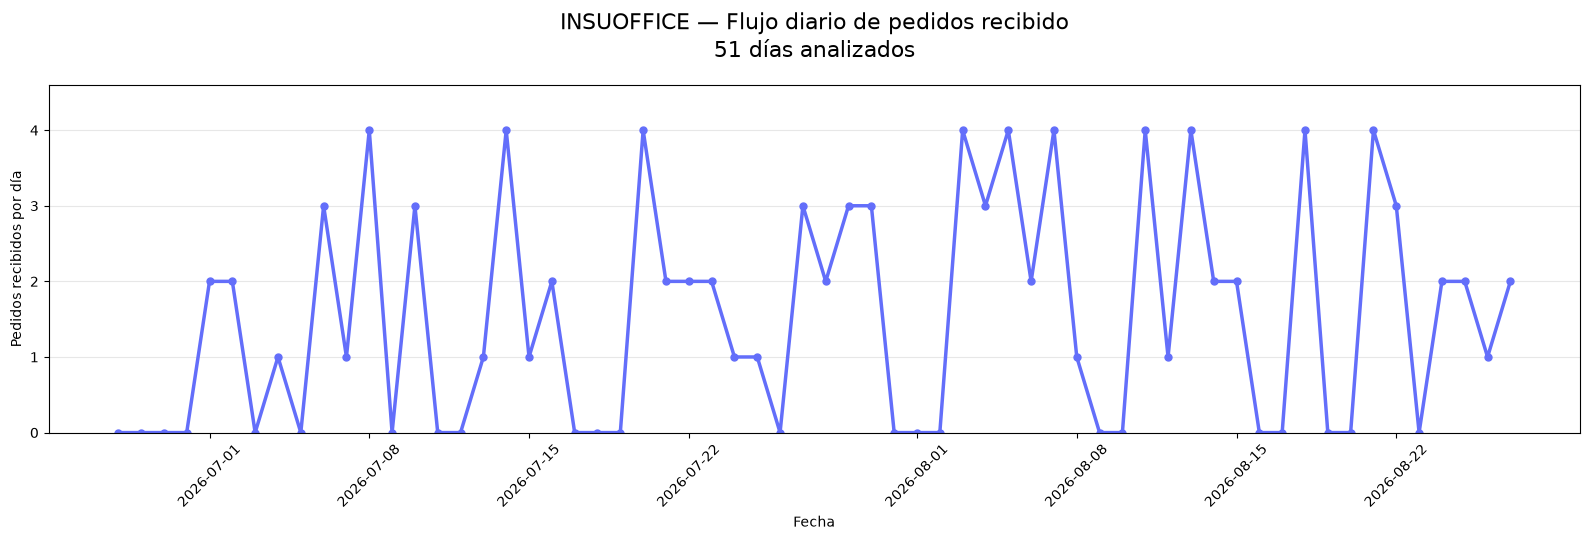

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/05_cliente_top_2.png


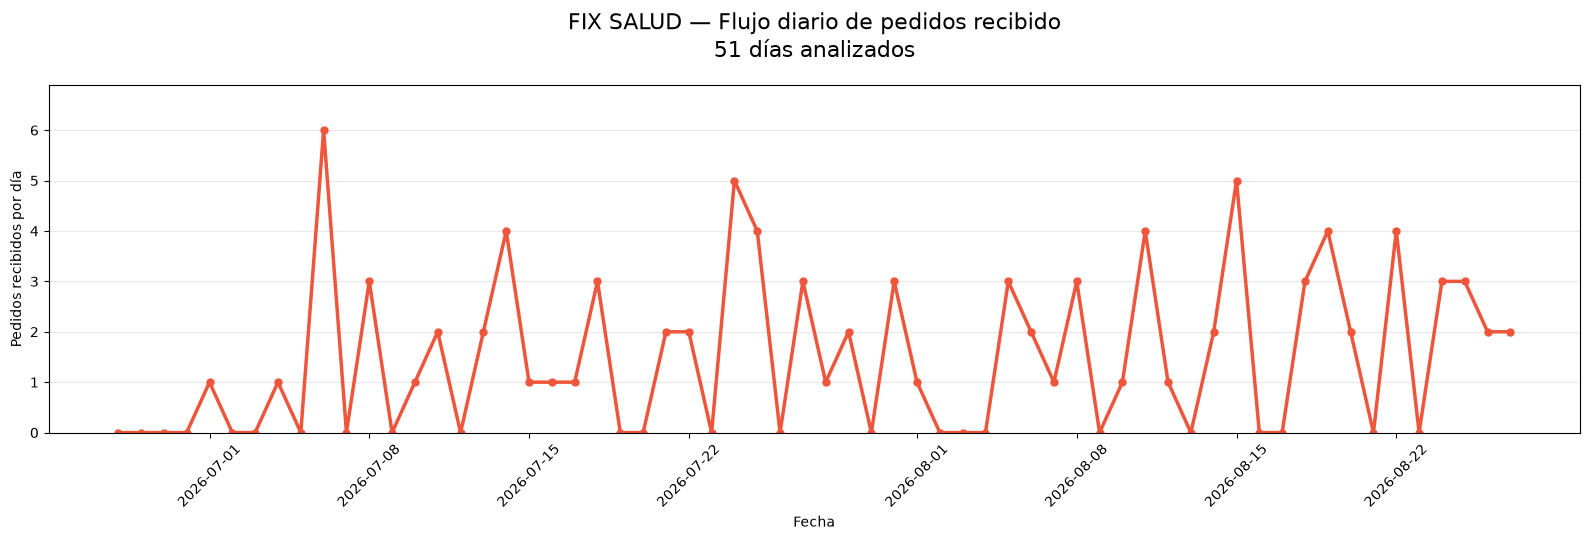

Gráfico guardado en: /home/sebi/WYNFLEX/outputs/visualizaciones/05_cliente_top_3.png


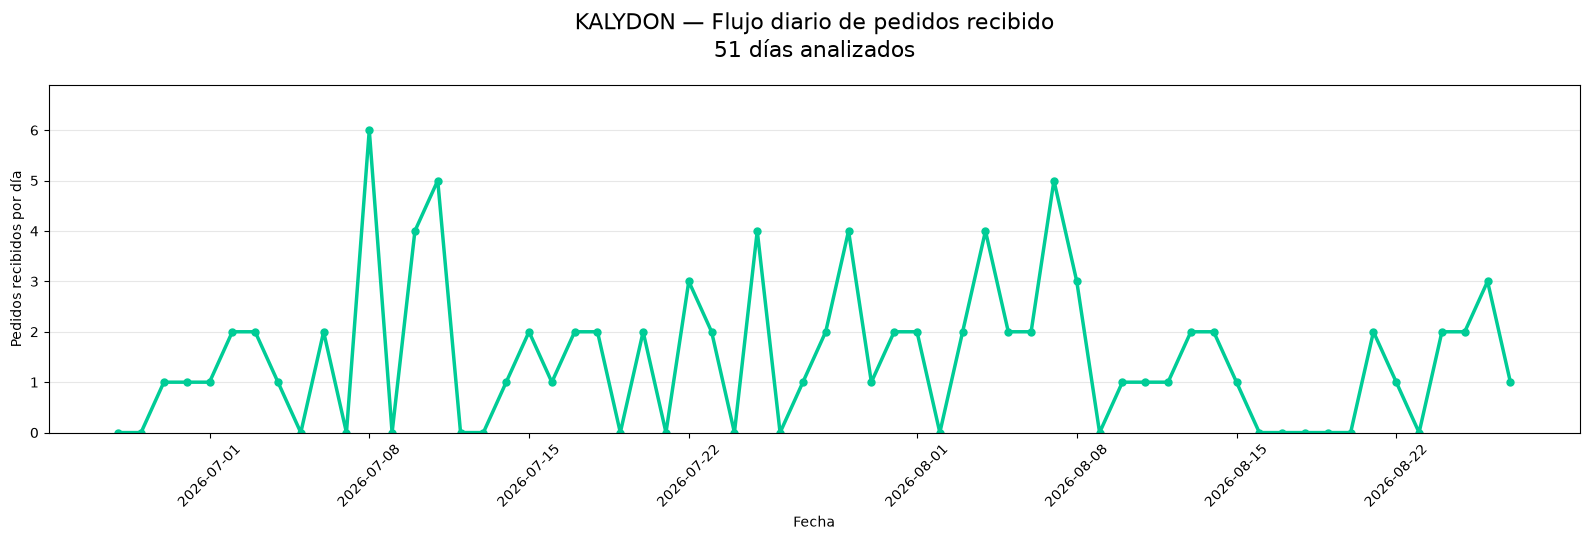

In [12]:
# ============================================================
# VARIACIÓN DIARIA DEL FLUJO DE PEDIDOS — TOP 3 CLIENTES
# ============================================================

top_clientes = (
    df_entregas
    .groupby("nombre_fantasia")
    .size()
    .sort_values(ascending=False)
    .head(3)
    .index
)

colores = [
    "#636EFA",
    "#EF553B",
    "#00CC96",
]

fechas = pd.date_range(
    start=df_entregas["fecha_colecta"].min().normalize(),
    end=df_entregas["fecha_colecta"].max().normalize(),
    freq="D"
)


# ============================================================
# GRÁFICOS INDIVIDUALES
# ============================================================

for i, (cliente, color) in enumerate(
    zip(top_clientes, colores),
    start=1
):

    df_cliente = df_entregas[
        df_entregas["nombre_fantasia"] == cliente
    ].copy()

    df_cliente["fecha"] = (
        df_cliente["fecha_colecta"]
        .dt.normalize()
    )

    df_cliente = (
        df_cliente
        .groupby("fecha")
        .size()
        .reset_index(name="pedidos")
    )

    df_cliente = (
        df_cliente
        .set_index("fecha")
        .reindex(
            fechas,
            fill_value=0
        )
        .rename_axis("fecha")
        .reset_index()
    )


    # ========================================================
    # GRÁFICO
    # ========================================================

    fig, ax = plt.subplots(figsize=(16, 5.5))

    ax.plot(
        df_cliente["fecha"],
        df_cliente["pedidos"],
        marker="o",
        linewidth=2.5,
        markersize=5,
        color=color
    )

    ax.set_title(
        f"{cliente} — Flujo diario de pedidos recibido\n"
        f"{dias_analizados} días analizados",
        fontsize=16,
        pad=20
    )

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Pedidos recibidos por día")

    ax.tick_params(axis="x", rotation=45)

    ax.set_ylim(
        0,
        df_cliente["pedidos"].max() * 1.15
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()


    # Guardar PNG
    ruta = OUTPUT_DIR / f"05_cliente_top_{i}.png"

    fig.savefig(
        ruta,
        dpi=150,
        bbox_inches="tight"
    )

    print(f"Gráfico guardado en: {ruta}")

    plt.show()

# 10. Conclusiones

El análisis permite transformar los registros de entregas gestionados por el cadete en indicadores útiles para comprender el comportamiento de la operación durante el período analizado.

Los principales resultados se organizan en cuatro dimensiones:

- **Eficiencia operativa:** el porcentaje de entregas que alcanzan el estado "Entregado" permite evaluar el nivel de cumplimiento del cadete sobre los pedidos recibidos.
- **Evolución temporal:** el análisis diario permite identificar variaciones en la carga de trabajo y patrones recurrentes, como una mayor actividad al comienzo de la semana.
- **Clientes:** el volumen de pedidos recibidos permite identificar las principales cuentas atendidas y analizar cómo varía el flujo de pedidos de cada una a lo largo del tiempo.
- **Distribución geográfica:** el dataset geográfico desarrollado para WYNFLEX permite identificar las zonas y barrios donde se concentra la mayor cantidad de entregas.

Un aspecto destacado del proyecto es la construcción de un **dataset geográfico reutilizable de direcciones**, que incorpora información como barrio, coordenadas y código postal geocodificado. El uso de un cache permite ampliar progresivamente esta base sin repetir innecesariamente el procesamiento de direcciones ya conocidas.

En conjunto, los análisis convierten datos operativos en información que puede utilizarse para comprender la carga de trabajo, detectar patrones y apoyar la planificación de recorridos y recursos.

> **Alcance del análisis:** los resultados representan exclusivamente los pedidos gestionados por el cadete y disponibles en este dataset durante el período analizado. No representan la totalidad de las operaciones de WYNFLEX ni el volumen total generado por cada cliente.

Este análisis constituye además una base para futuras etapas del proyecto, como la incorporación de métricas de tiempos de entrega, productividad, costos operativos, dashboards en Power BI y despliegue sobre Azure.

**Próximo objetivo:** evolucionar el pipeline hacia una solución automatizada de Data Engineering con almacenamiento cloud, reporting y Continuous Deployment (CD).